# Spotify Recommendor Algorithm
### Collaborators: Aisha Mardini, Lilly Peters, Shinung Li

- Our dataset is from: https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset \

\
___Elements___

- **track_id:** The Spotify ID for the song
- **artists:** The artists' names. If there is more than one artist, they are separated by a ;
- **album_name:** The album name
- **track_name:** Name of the track
- **popularity:** The popularity is calculated by Spotify's algorithm from [0,100]. Based on the total number of plays the track has had and how recent those plays are. 
- **duration_ms:** The song length in milliseconds
- **explicit:** Whether or not the song has explicit lyrics (true = yes; false = no OR unknown)
- **danceability:** How suitable a track is for dancing from [0,1] based on a combination of elements including tempo, rhythm stability, beat strength, and overall regularity. 
- **energy:** Represents a perceptual measure of intensity and activity from [0,1]. Typically, energetic tracks feel fast, loud, and noisy. 
- **key:** The key the track is in mapped using standard Pitch Class notation. E.g. 0 = C, 1 = C♯/D♭, 2 = D, and so on. If no key was detected, the value is -1
- **loudness:** How loud the track is in decibels
- **mode:** Mode indicates the modality (major or minor) of a trackMajor is represented by 1 and minor is 0
- **speechiness:** Speechiness detects the presence of spoken words in a track from [0,1]
- **acousticness:** Whether the track is acoustic from [0,1]. 1.0 represents high confidence the track is acoustic
- **instrumentalness:** Predicts whether a track contains no vocals from [0,1]
- **liveness:** Detects the presence of an audience in the recording from [0,1]
- **valence:** Musical positiveness conveyed by a track from [0,1]. Tracks with high valence sound more positive (e.g. happy, cheerful, euphoric), while tracks with low valence sound more negative (e.g. sad, depressed, angry)
- **tempo:** Estimated tempo of a track in beats per minute (BPM). 
- **time_signature:** An estimated time signature. The time signature (meter) is a notational convention to specify how many beats are in each bar (or measure). The time signature ranges from 3 to 7 indicating time signatures of 3/4, to 7/4.
- **track_genre:** The genre of the song

## Step 1:
- Upload the data
- Data cleaning and preprocessing

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Loading in the dataset
df_read = pd.read_csv('/Users/aishamardini/Downloads/dataset.csv')
df_read.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [5]:
# checking if there are NaN values in track id, artists, albums
df_read[df_read["track_id"].isna()]

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre


In [11]:
df_read[df_read["artists"].isna()]

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
65900,65900,1kR4gIb7nGxHPI3D2ifs59,NaN,NaN,NaN,0,0,False,0.501,0.583,...,-9.46,0,0.0605,0.69,0.00396,0.0747,0.734,138.391,4,k-pop


In [9]:
df_read[df_read["album_name"].isna()]

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
65900,65900,1kR4gIb7nGxHPI3D2ifs59,NaN,NaN,NaN,0,0,False,0.501,0.583,...,-9.46,0,0.0605,0.69,0.00396,0.0747,0.734,138.391,4,k-pop


In [39]:
# drop nan values
df_read = df_read.dropna()

In [41]:
# check to see if any rows are duplicates and drop them
#print(df_read.drop_duplicates().any())
df_read = df_read.drop_duplicates()

In [43]:
# checking the types for columns
df_read.dtypes

Unnamed: 0            int64
track_id             object
artists              object
album_name           object
track_name           object
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre          object
dtype: object

In [45]:
# check column names
df_read.columns

Index(['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name',
       'popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'track_genre'],
      dtype='object')

In [47]:
df.columns

Index(['track_id', 'artists', 'album_name', 'track_name', 'popularity',
       'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness',
       'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'time_signature', 'track_genre'],
      dtype='object')

In [49]:
# drop the unnamed column
df = df_read.drop(columns=['Unnamed: 0'])

In [51]:
# check statistics
df.describe()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,113999.000000,1.139990e+05,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000
mean,33.238827,2.280312e+05,0.566801,0.641383,5.309126,-8.258950,0.637558,0.084652,0.314907,0.156051,0.213554,0.474066,122.147695,3.904034
std,22.304959,1.072961e+05,0.173543,0.251530,3.559999,5.029357,0.480708,0.105733,0.332522,0.309556,0.190378,0.259261,29.978290,0.432623
min,0.000000,8.586000e+03,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218500,4.000000
50%,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.597500,0.049000,0.273000,0.683000,140.071000,4.000000
max,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [53]:
# check to see if multiartists are separated by semicolon
df[df["artists"].str.contains(";")]["artists"].unique()[:20]

array(['Ingrid Michaelson;ZAYN', 'A Great Big World;Christina Aguilera',
       'Jason Mraz;Colbie Caillat', 'Chord Overstreet;Deepend',
       'Andrew Foy;Renee Foy', 'Boyce Avenue;Bea Miller',
       'Boyce Avenue;Jennel Garcia', 'Brandi Carlile;Sam Smith',
       'Brandi Carlile;Lucius', 'Eddie Vedder;Nusrat Fateh Ali Khan',
       'Boyce Avenue;Fifth Harmony', 'Gabrielle Aplin;JP Cooper',
       'Ray LaMontagne;Sierra Ferrell', 'Susie Suh;Robot Koch',
       'Tyler Ward;Lindsey Stirling;Kina Grannis', 'Eden Elf;Ren Avel',
       'Boyce Avenue;Rachel Grae', 'Zack Tabudlo;Yonnyboii',
       'Tyler Ward;Karis;Ray Lorraine', 'Agustín Amigó;Nylonwings'],
      dtype=object)

In [55]:
# how many loudness columns are 0
(df["loudness"] == 0).sum()

np.int64(0)

In [57]:
# how many instrumentalness columns are 0
(df["instrumentalness"] == 0).sum()

np.int64(38763)

In [59]:
# how many tempo columns are 0
(df["tempo"] == 0).sum()

np.int64(157)

In [61]:
# drop temp columns that are 0
df = df[df["tempo"] != 0]

In [63]:
# remove artist's duplicated songs
df = df.sort_values("popularity", ascending=False).drop_duplicates(subset=["track_name", "artists"], keep="first")

In [65]:
# check to see dropped
df.duplicated(subset=["track_name", "artists"]).sum()

np.int64(0)

In [67]:
# remove songs with popularity == 0
df = df[df["popularity"] > 0]

In [71]:
# check statistics again
df.describe()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,76444.000000,7.644400e+04,76444.000000,76444.000000,76444.000000,76444.000000,76444.000000,76444.000000,76444.000000,76444.000000,76444.000000,76444.000000,76444.000000,76444.000000
mean,37.437732,2.315885e+05,0.562729,0.641205,5.287269,-8.470715,0.633248,0.089821,0.322443,0.182218,0.220964,0.466495,122.644597,3.907462
std,17.848746,1.152993e+05,0.174637,0.254297,3.557360,5.139490,0.481921,0.118464,0.335078,0.329580,0.199582,0.261876,29.640805,0.418265
min,1.000000,2.426600e+04,0.051300,0.000020,0.000000,-46.591000,0.000000,0.022100,0.000000,0.000000,0.009250,0.000000,30.322000,0.000000
25%,23.000000,1.741060e+05,0.451000,0.465000,2.000000,-10.304250,0.000000,0.036100,0.014900,0.000000,0.098700,0.247000,99.952000,4.000000
50%,37.000000,2.157745e+05,0.576000,0.682000,5.000000,-7.224000,1.000000,0.049300,0.184000,0.000083,0.133000,0.452000,122.521500,4.000000
75%,50.000000,2.679060e+05,0.691000,0.859000,8.000000,-5.127000,1.000000,0.087700,0.613000,0.140000,0.285000,0.678000,140.815500,4.000000
max,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


## Step 2:
- Data Visualization

In [54]:
# check column names
df.columns

Index(['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name',
       'popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'track_genre'],
      dtype='object')

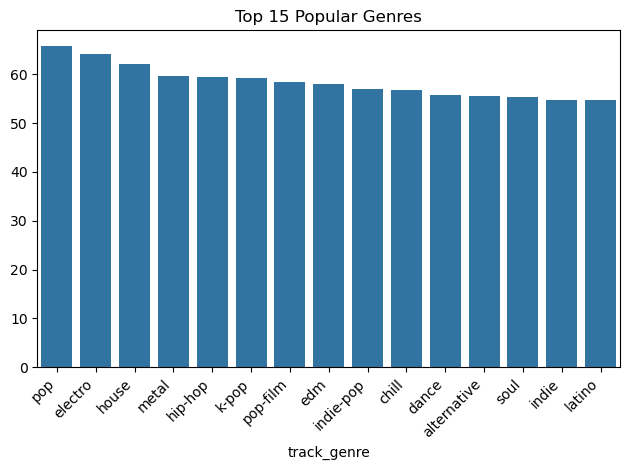

In [74]:
# bar plot of the first 15 most popular genres
plt.title("Top 15 Popular Genres")
genre_pop = df.groupby("track_genre")["popularity"].mean().sort_values(ascending=False).head(15)
sns.barplot(x=genre_pop.index, y=genre_pop.values)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

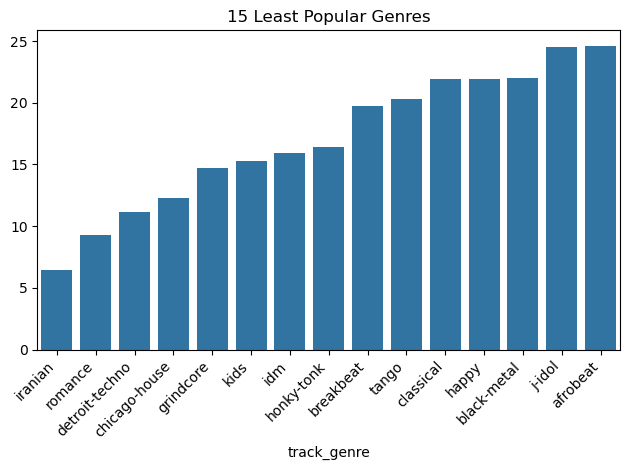

In [76]:
# plot for the 15 least popular genres
plt.title("15 Least Popular Genres")
genre_pop = df.groupby("track_genre")["popularity"].mean().sort_values(ascending=True).head(15)
sns.barplot(x=genre_pop.index, y=genre_pop.values)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

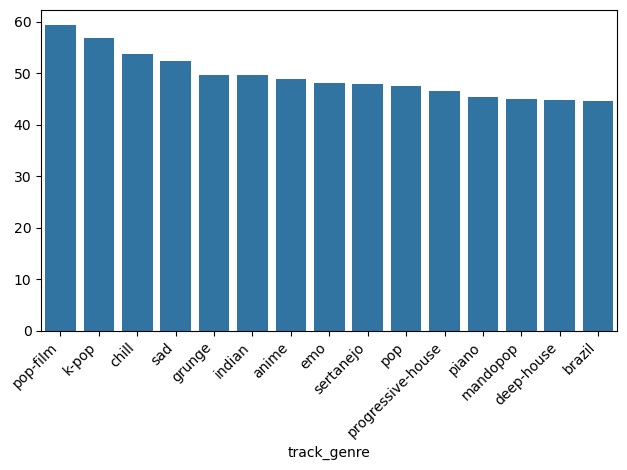

In [58]:
genre_pop = df.groupby("track_genre")["popularity"].mean().sort_values(ascending=False).head(15)
sns.barplot(x=genre_pop.index, y=genre_pop.values)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

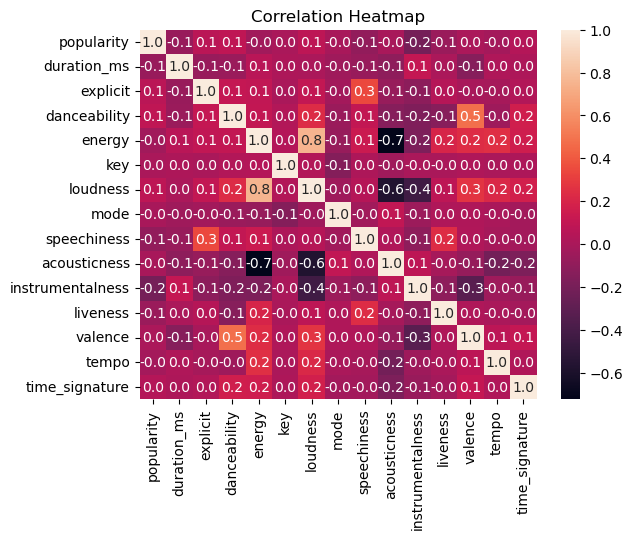

In [78]:
# heatmap plot correlating features
plt.title("Correlation Heatmap")
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".1f")
plt.show()

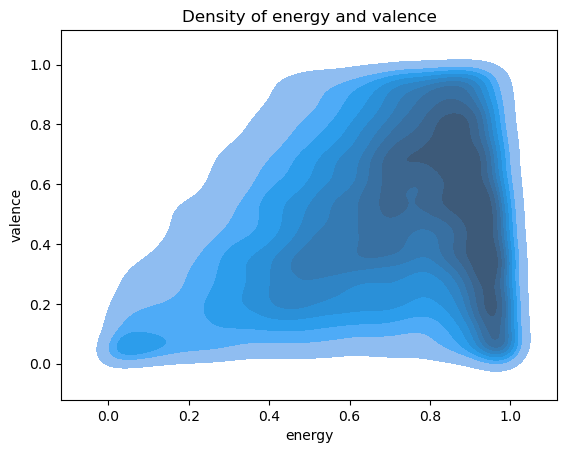

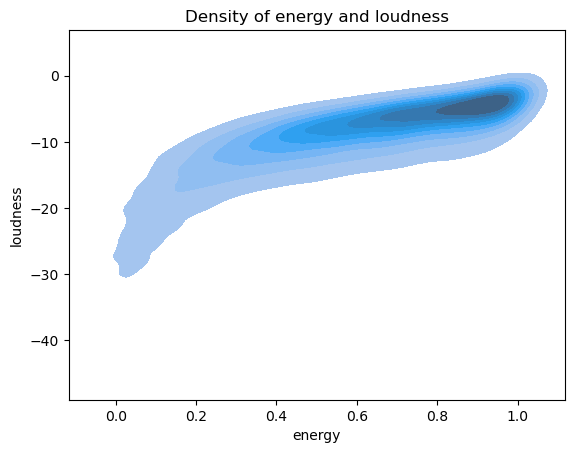

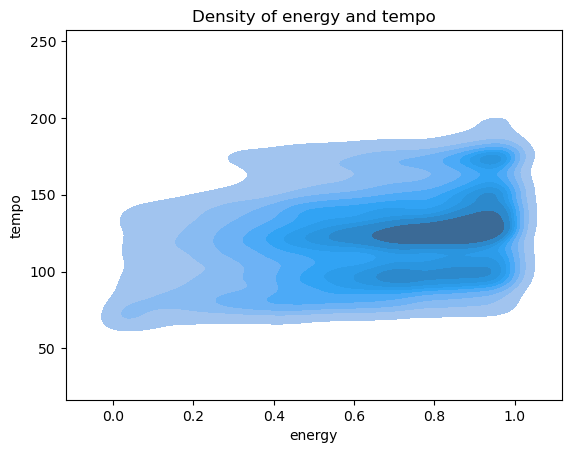

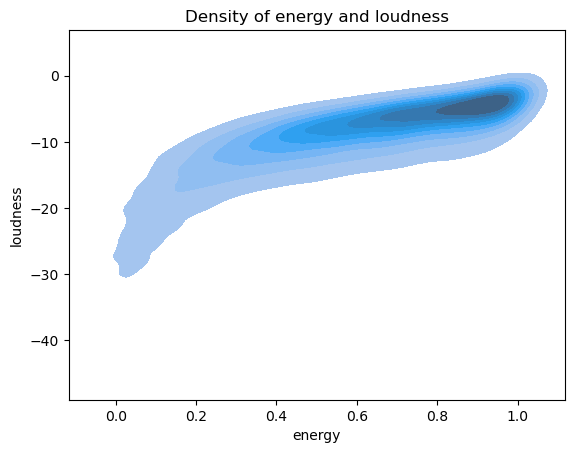

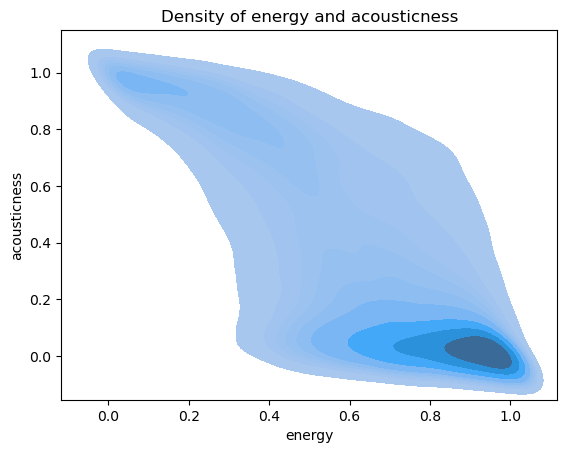

In [80]:
# 5 density plots comparing features with energy
# way to see how well songs can be correlated

features = ["valence","loudness","tempo","loudness", "acousticness"]

for f in features:
    sns.kdeplot(data=df,x="energy",y=f,fill=True,levels=10)
    plt.title(f"Density of energy and {f}")
    plt.show()